In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import plotly.express as px
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor,XGBClassifier
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,confusion_matrix,classification_report

In [3]:
df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [351]:
df['parental_education']=df['parental_education'].fillna(df['parental_education'].mode()[0])

In [353]:
df.dropna(inplace=True)

<Figure size 1500x600 with 0 Axes>

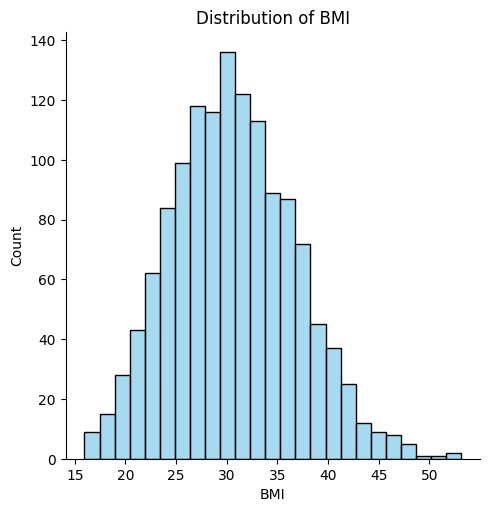

In [10]:
plt.figure(figsize=(15,6))
sns.displot(x=df['bmi'], color='skyblue')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [18]:
fig = px.pie(
    df,
    names="sex",
    color='smoker',
    hole=0.4,
    title="Age Distribution"
)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()

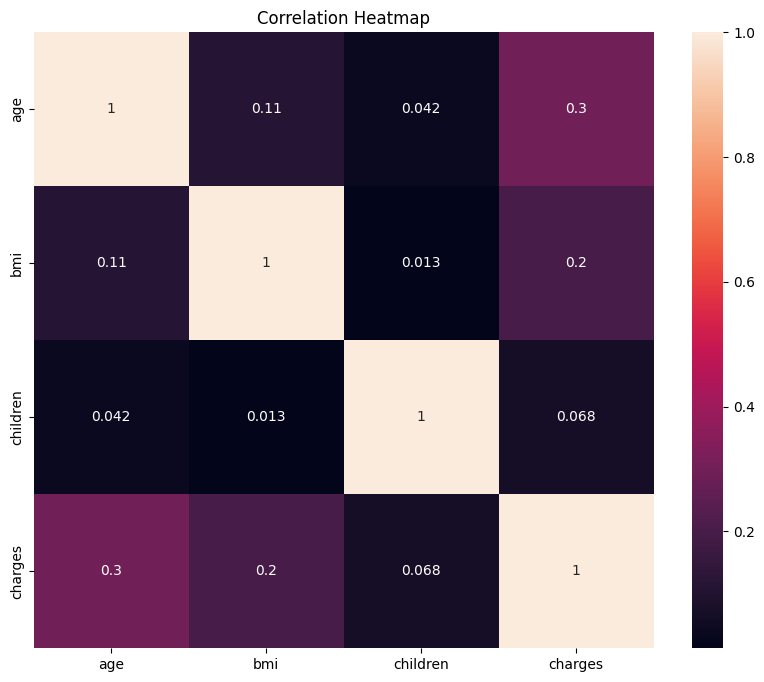

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [21]:
one=LabelEncoder()
df['sex']=one.fit_transform(df['sex'])
df['smoker']=one.fit_transform(df['smoker'])
df['region']=one.fit_transform(df['region'])

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [23]:
x=df[[ 'age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y=df['charges']

In [24]:
x = pd.get_dummies(x, drop_first=True)

In [25]:
x_test ,x_train ,y_test ,y_train =train_test_split(x,y,random_state=42,test_size=0.2)

In [26]:
sca=StandardScaler()
x_train_sca=sca.fit_transform(x_train)
x_test_sca=sca.transform(x_test)

In [27]:
from turtle import pen


ra=RandomForestRegressor(n_estimators=200,max_depth=11,min_samples_split=10,min_samples_leaf=10,random_state=42,n_jobs=-1)

la=LinearRegression()

dt=DecisionTreeRegressor(max_depth=10,min_samples_split=10,min_samples_leaf=10,random_state=42)
                                                    
xgb=XGBRegressor(n_estimators=200,random_state=42,learning_rate=0.01,subsample=0.8,colsample_bytree=0.8,max_depth=10,objective='reg:squarederror',n_jobs=-1)


In [28]:
ra.fit(x_train_sca,y_train)
y_pred=ra.predict(x_test_sca)
print(f'R2 Score of  RandomForestRegressor: {r2_score(y_test, y_pred)}')
print(f'Mean Squared Error of RandomForestRegressor: {mean_squared_error(y_test, y_pred)}')
print(f'Mean Absolute Error of RandomForestRegressor: {mean_absolute_error(y_test, y_pred)}')

R2 Score of  RandomForestRegressor: 0.834723207548604
Mean Squared Error of RandomForestRegressor: 23854998.07600313
Mean Absolute Error of RandomForestRegressor: 2871.8088742435943


In [29]:
la.fit(x_train_sca,y_train)
y_pre=la.predict(x_test_sca)
print(f'R2 Score of  LinearRegression: {r2_score(y_test, y_pre)}')
print(f'Mean Squared Error of LinearRegression: {mean_squared_error(y_test, y_pre)}')
print(f'Mean Absolute Error of LinearRegression: {mean_absolute_error(y_test, y_pre)}')

R2 Score of  LinearRegression: 0.7365630152770473
Mean Squared Error of LinearRegression: 38022814.1562111
Mean Absolute Error of LinearRegression: 4134.561064719069


In [30]:
dt.fit(x_train_sca,y_train)
y_pr=dt.predict(x_test_sca)
print(f'R2 Score Decision Tree: {r2_score(y_test, y_pr)}')
print(f'Mean Squared Error Decision Tree: {mean_squared_error(y_test, y_pr)}')
print(f'Mean Absolute Error Decision Tree: {mean_absolute_error(y_test, y_pr)}')

R2 Score Decision Tree: 0.8240454139838814
Mean Squared Error Decision Tree: 25396162.695453994
Mean Absolute Error Decision Tree: 2886.82219268949


In [31]:
xgb.fit(x_train_sca,y_train)
y_prea=xgb.predict(x_test_sca)
print(f'R2 Score XGBoost: {r2_score(y_test, y_prea)}')
print(f'Mean Squared Error XGBoost: {mean_squared_error(y_test, y_prea)}')
print(f'Mean Absolute Error XGBoost: {mean_absolute_error(y_test, y_prea)}')    

R2 Score XGBoost: 0.7392720251412074
Mean Squared Error XGBoost: 37631812.95066424
Mean Absolute Error XGBoost: 4315.14734331469


In [ ]:
# Plot feature importances for all trained models in a 2x2 subplot grid
features = list(x.columns)

models = {
    "RandomForestRegressor": getattr(ra, "feature_importances_", None),
    "DecisionTreeRegressor": getattr(dt, "feature_importances_", None),
    "XGBRegressor": getattr(xgb, "feature_importances_", None),
    "LinearRegression (abs coef)": np.abs(getattr(la, "coef_", None))
}

# prepare normalized importances (handle None gracefully)
importances = {}
for name, vals in models.items():
    if vals is None:
        importances[name] = np.zeros(len(features))
    else:
        arr = np.array(vals, dtype=float)
        # if length mismatch, try to align by first N features
        if arr.size != len(features):
            arr = arr.flatten()[: len(features)]
        # normalize to sum 1 for comparability
        s = arr.sum()
        importances[name] = arr / s if s != 0 else arr

# plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, (name, imp) in zip(axes, importances.items()):
    ser = pd.Series(imp, index=features).sort_values()
    ax.barh(ser.index, ser.values, color="C0")
    ax.set_title(name)
    ax.set_xlabel("Normalized importance")
    ax.set_xlim(0, ser.max() * 1.1)
plt.tight_layout()
plt.show()